# STalign parity: `merfish-merfish-alignment-affine-only-with-points.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/merfish-merfish-alignment-affine-only-with-points.ipynb).

Status: `compared-affine`. 


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 0.003715172363973073,
  "AI relative L2": 0.034888142021525105,
  "L relative L2": 0.003482620729718523,
  "affine relative L2": 0.0010784799052528033,
  "df1[Unnamed: 0] label disagreement": 0.0,
  "df1[Unnamed: 0] label set jaccard": 1.0,
  "df1[Unnamed: 0] labels only squidpy": 0.0,
  "df1[Unnamed: 0] labels only upstream": 0.0,
  "df1[center_x] median abs delta": 0.0,
  "df1[center_y] median abs delta": 0.0,
  "df1[max_x] median abs delta": 0.0,
  "df1[max_y] median abs delta": 0.0,
  "df1[min_x] median abs delta": 0.0,
  "df1[min_y] median abs delta": 0.0,
  "df1[volume] median abs delta": 0.0,
  "df2[Unnamed: 0] label disagreement": 0.0,
  "df2[Unnamed: 0] label set jaccard": 1.0,
  "df2[Unnamed: 0] labels only squidpy": 0.0,
  "df2[Unnamed: 0] labels only upstream": 0.0,
  "df2[center_x] median abs delta": 0.0,
  "df2[center_y] median abs delta": 0.0,
  "df2[max_x] median abs delta": 0.0,
  "df2[max_y] median abs delta": 0.0,
  "df2[min_x] median abs delta":

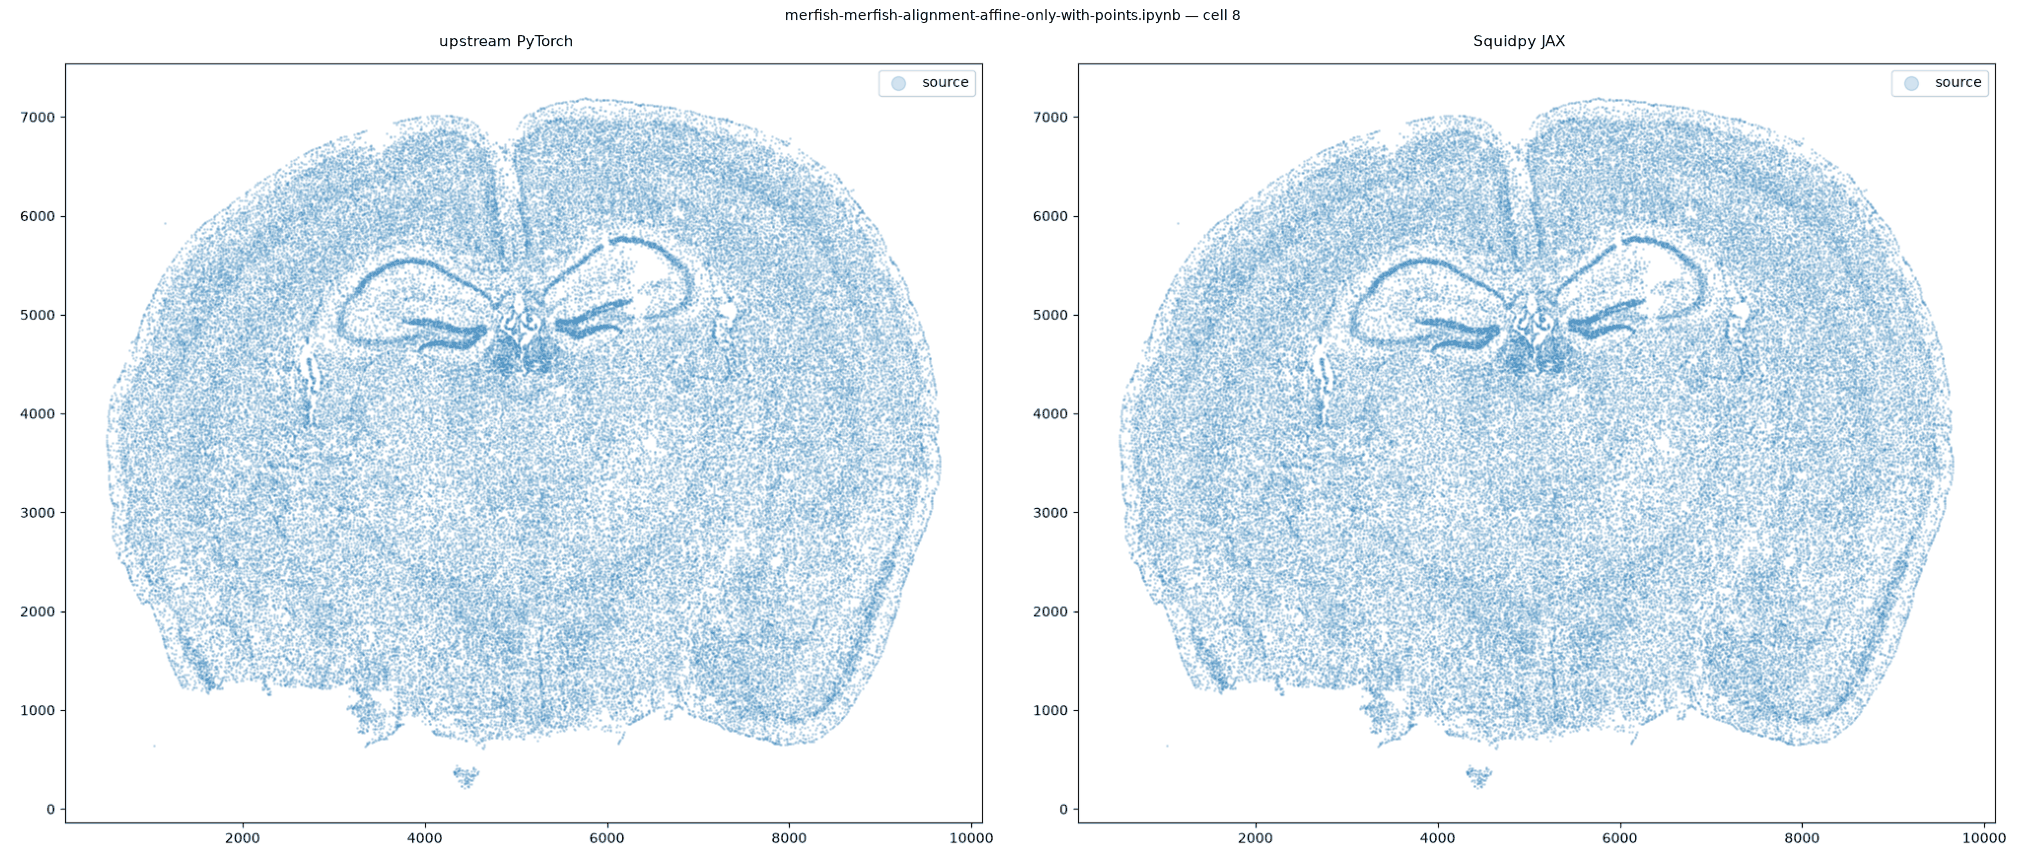

In [2]:
# get cell centroid coordinates
xI = np.array(df1['center_x'])
yI = np.array(df1['center_y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2, label='source')
ax.legend(markerscale = 10)

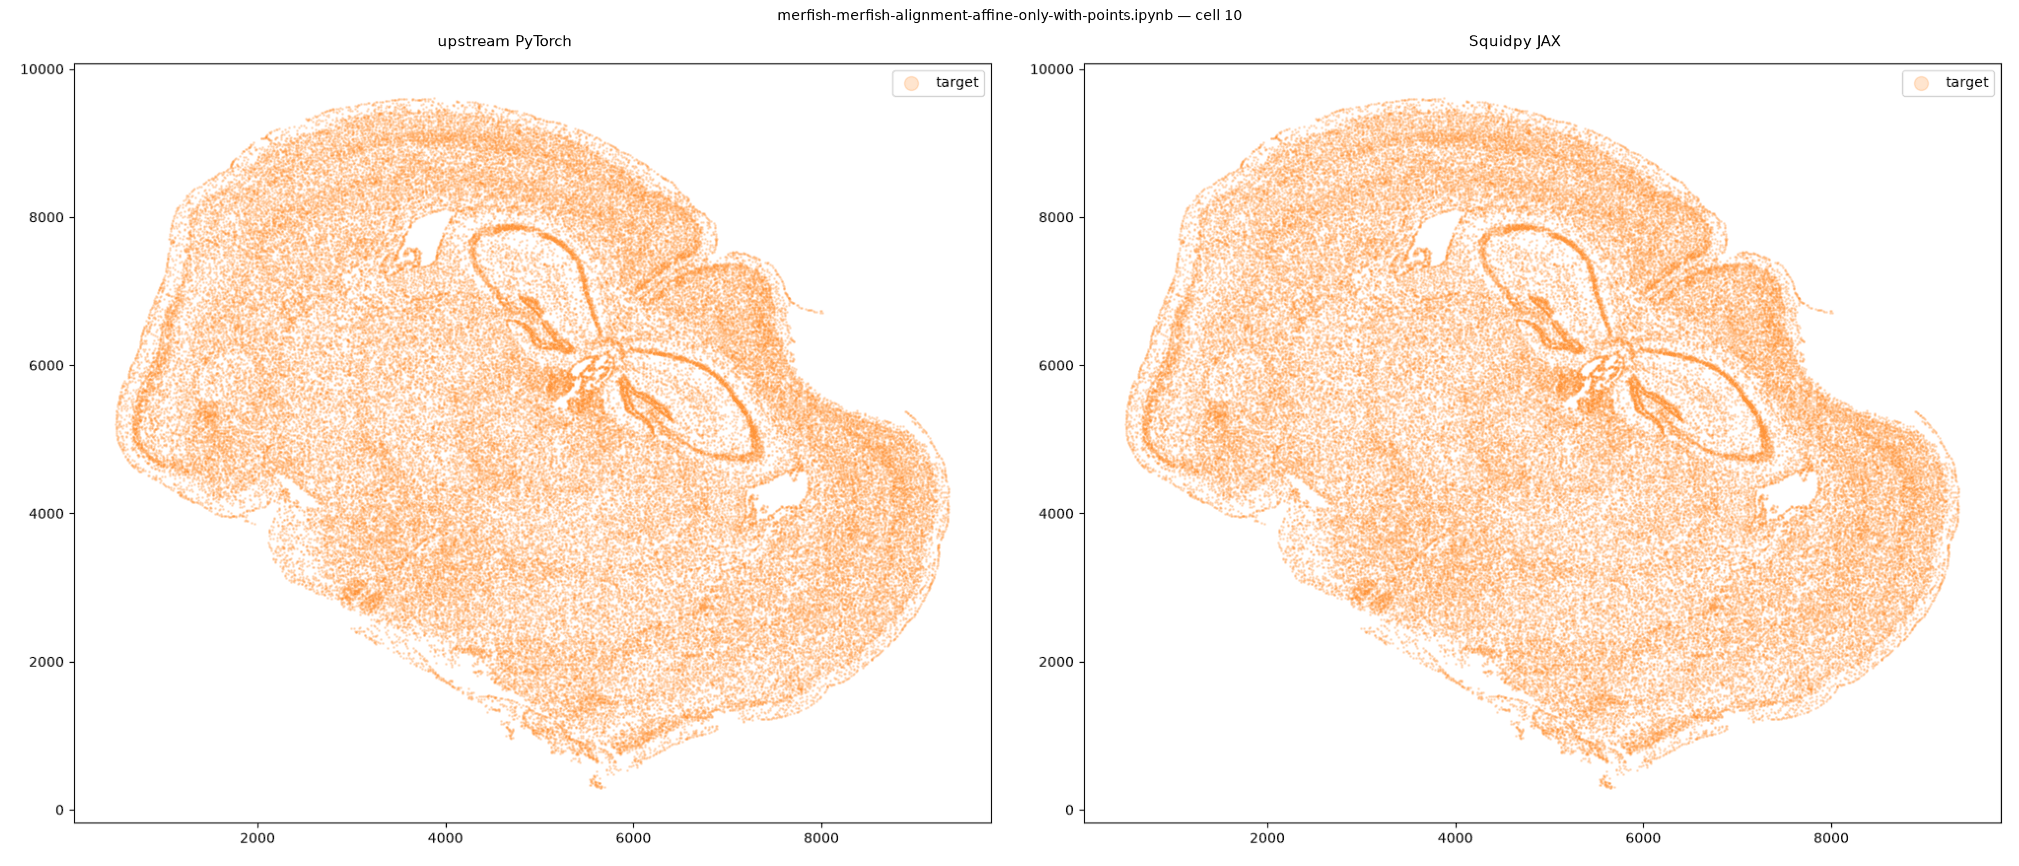

In [3]:
# Single cell data 2
# read in data
fname = '../merfish_data/datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate2_cell_metadata_S2R2.csv.gz'

df2 = pd.read_csv(fname)

# get cell centroids
xJ = np.array(df2['center_x'])
yJ = np.array(df2['center_y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xJ,yJ,s=1,alpha=0.2,c='#ff7f0e', label='target')
ax.legend(markerscale = 10)

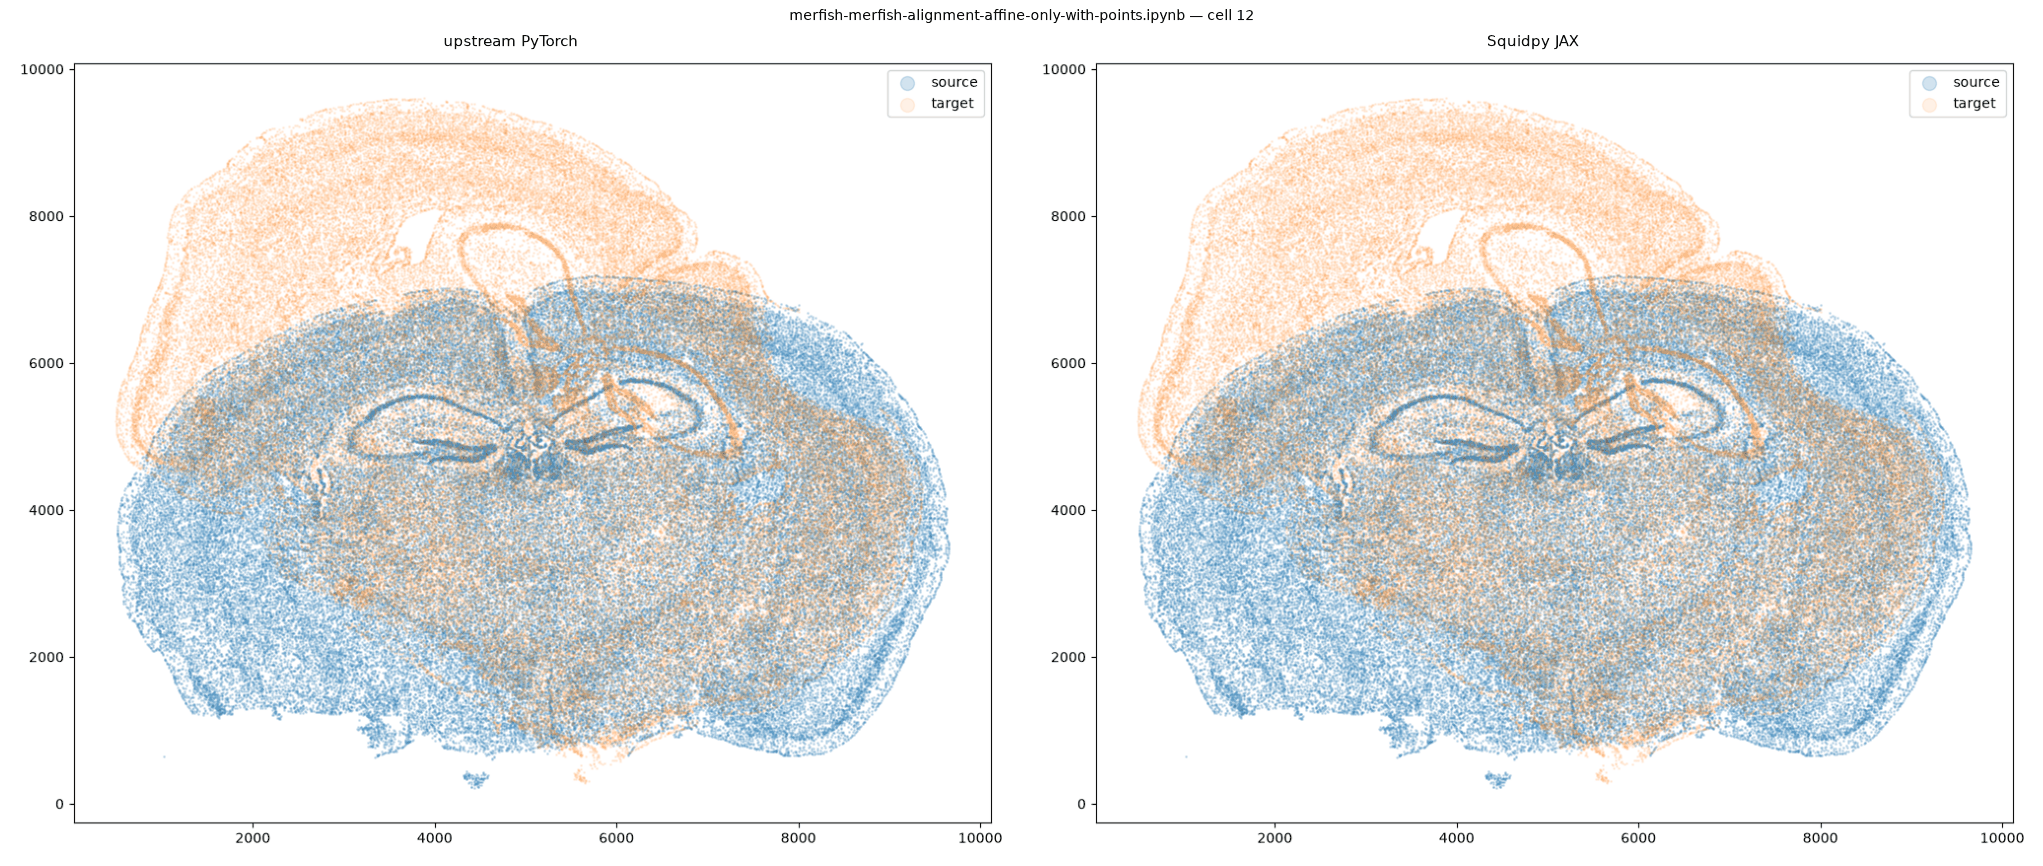

In [4]:
# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2, label='source')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label= 'target')
ax.legend(markerscale = 10)

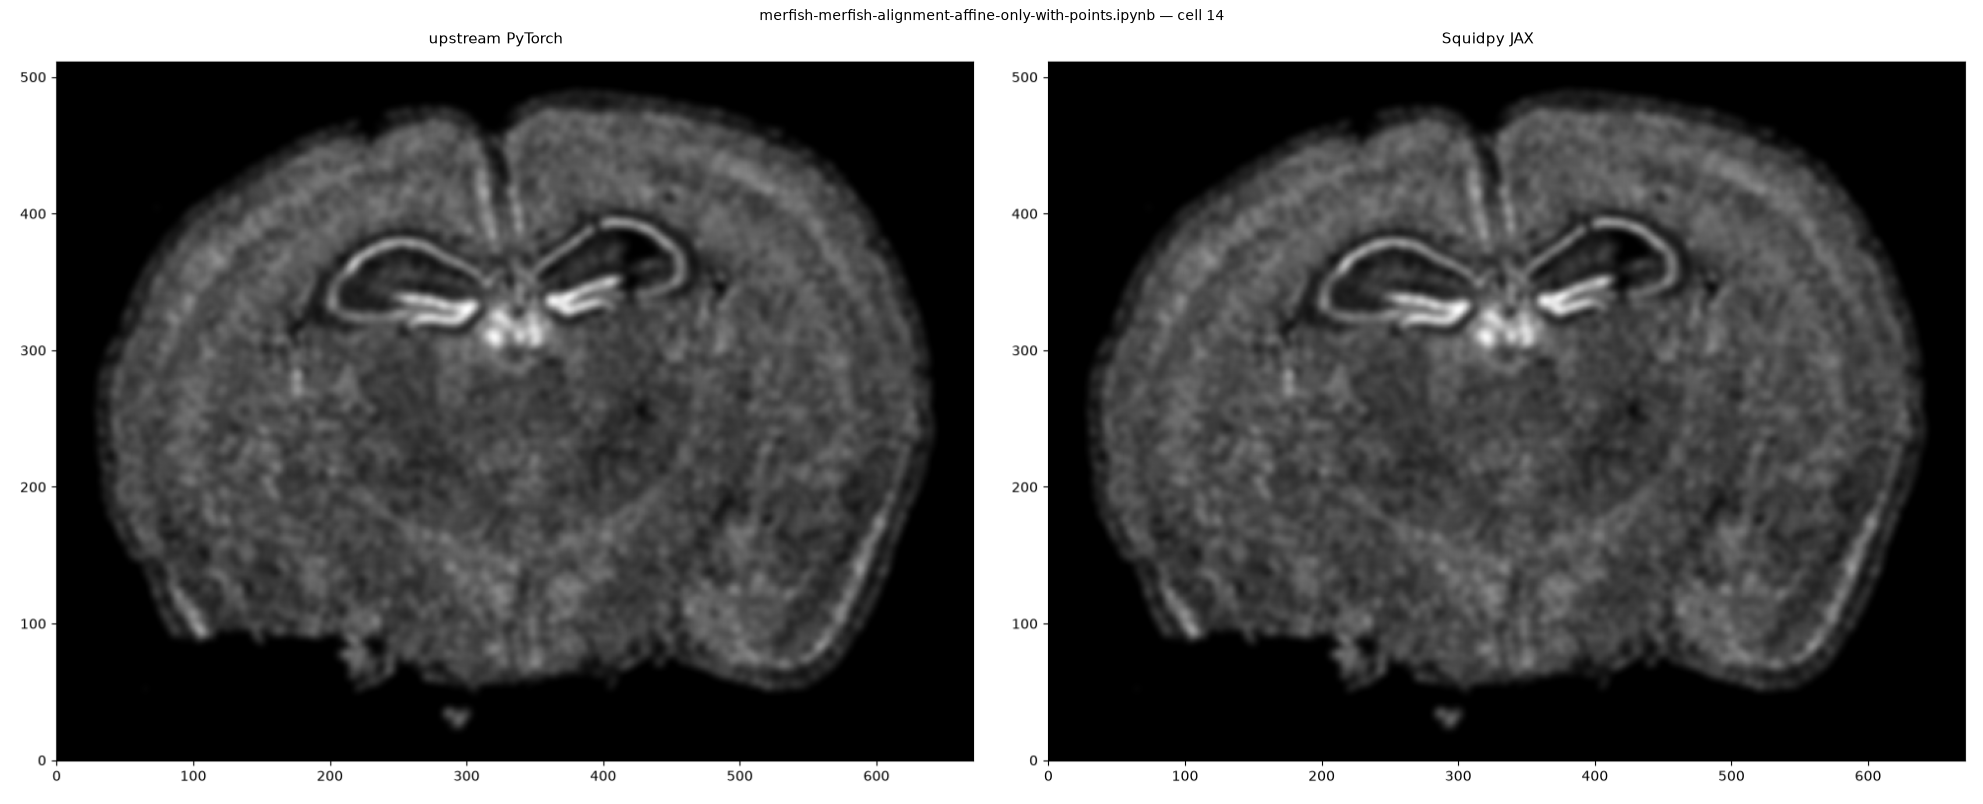

In [5]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI,yI,dx=15,blur=1.5)

# plot
ax = fig.axes[0]
ax.invert_yaxis()

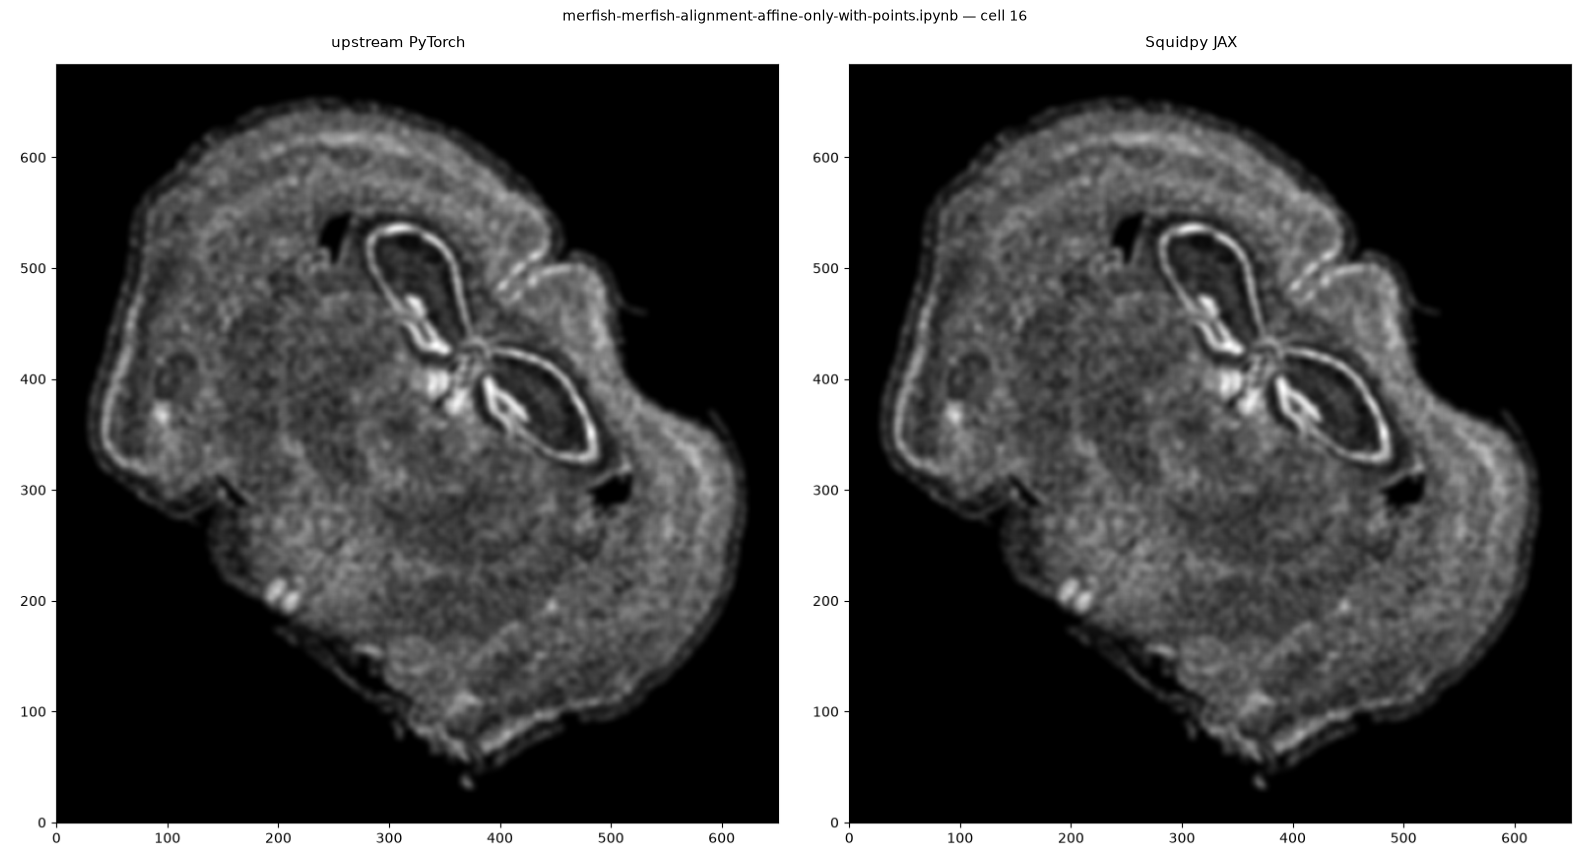

In [6]:
# rasterize and plot
XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=15, blur=1.5)
ax = fig.axes[0]
ax.invert_yaxis()

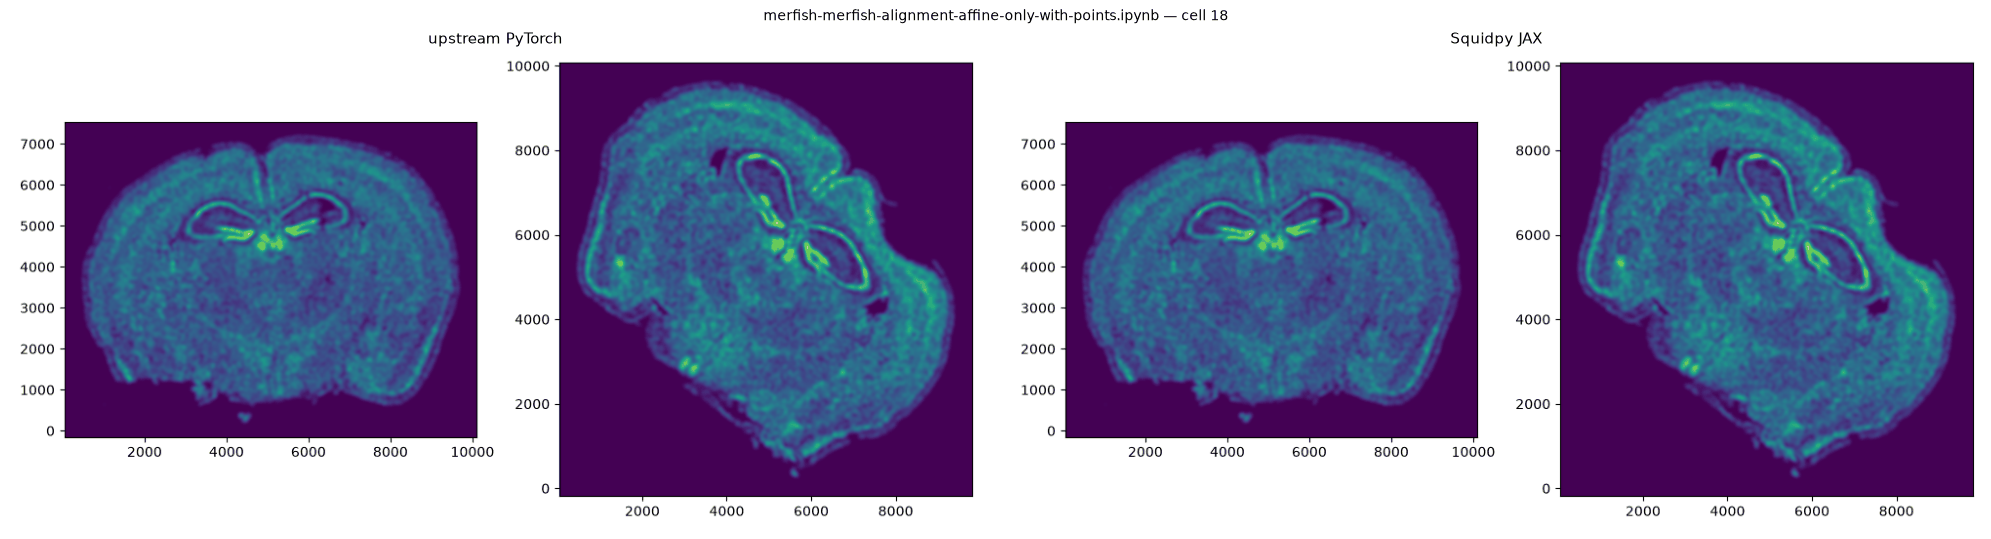

In [7]:
# get extent of images
extentI = STalign.extent_from_x((YI,XI))
extentJ = STalign.extent_from_x((YJ,XJ))

# plot rasterized images
fig,ax = plt.subplots(1,2)
ax[0].imshow(I.transpose(1,2,0).squeeze(), extent=extentI) 
ax[1].imshow(J.transpose(1,2,0).squeeze(), extent=extentJ)
ax[0].invert_yaxis()
ax[1].invert_yaxis()

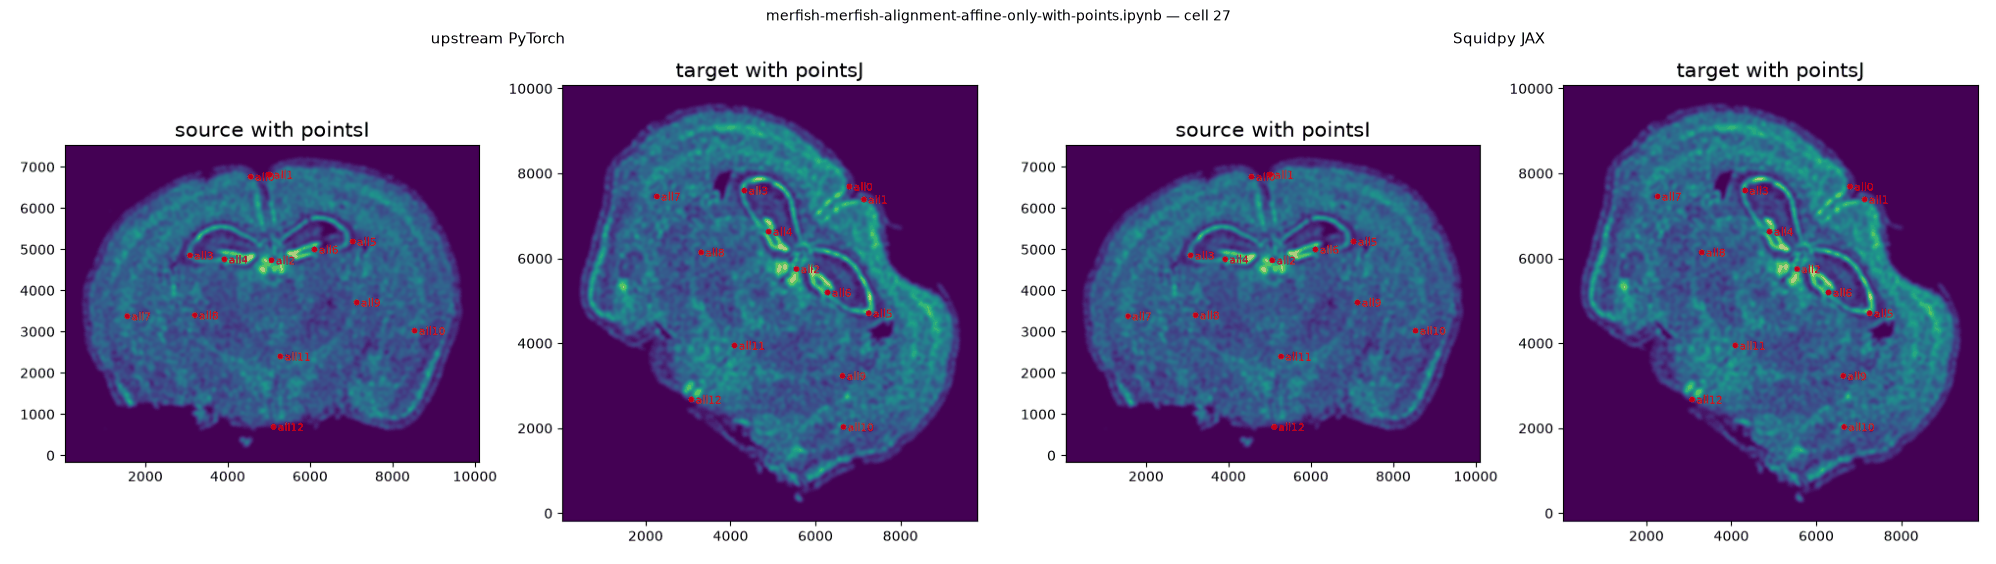

In [8]:
# plot

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) 
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

trans_offset_0 = mtransforms.offset_copy(ax[0].transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')
trans_offset_1 = mtransforms.offset_copy(ax[1].transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='red', s=10)
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='red', s=10)
    
for i in pointsIlist.keys():
    for j in range(len(pointsIlist[i])):
        ax[0].text(pointsIlist[i][j][0], pointsIlist[i][j][1],f'{i}{j}', c='red', transform=trans_offset_0, fontsize= 8)
for i in pointsJlist.keys():
    for j in range(len(pointsJlist[i])):
        ax[1].text(pointsJlist[i][j][0], pointsJlist[i][j][1],f'{i}{j}', c='red', transform=trans_offset_1, fontsize= 8)
        
ax[0].set_title('source with pointsI', fontsize=15)
ax[1].set_title('target with pointsJ', fontsize=15)

# invert only rasterized images
ax[0].invert_yaxis()
ax[1].invert_yaxis()

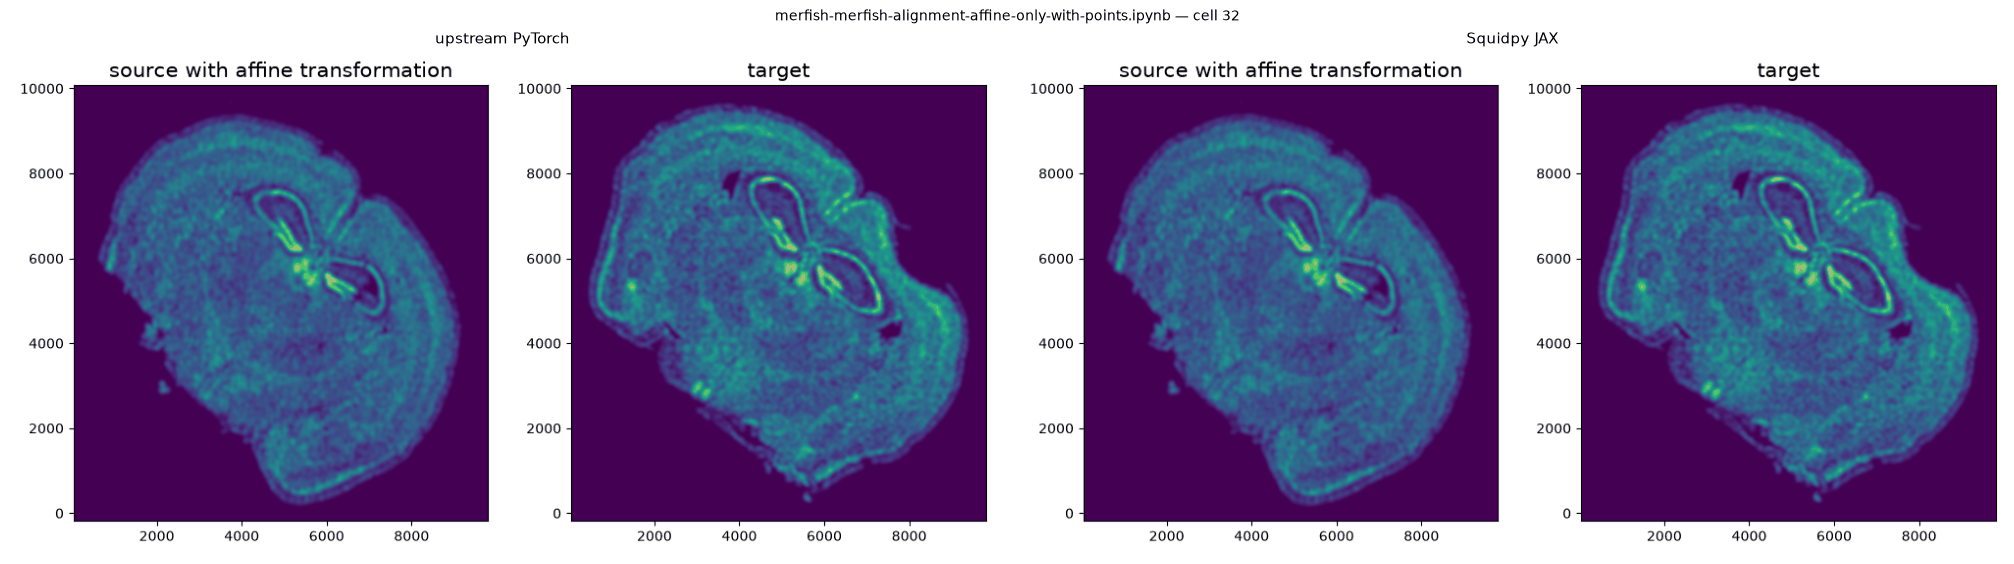

In [9]:
# compute initial affine transformation from points
AI= STalign.transform_image_source_with_A(A, [YI,XI], I, [YJ,XJ])

fig,ax = plt.subplots(1,2)

if AI.is_cuda:
    ax[0].imshow((AI.cpu().permute(1,2,0).squeeze()), extent=extentJ) 
else:
    ax[0].imshow((AI.permute(1,2,0).squeeze()), extent=extentJ) 
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) 

ax[0].set_title('source with affine transformation', fontsize=15)
ax[1].set_title('target', fontsize=15)

# invert only rasterized images
ax[0].invert_yaxis()
ax[1].invert_yaxis()

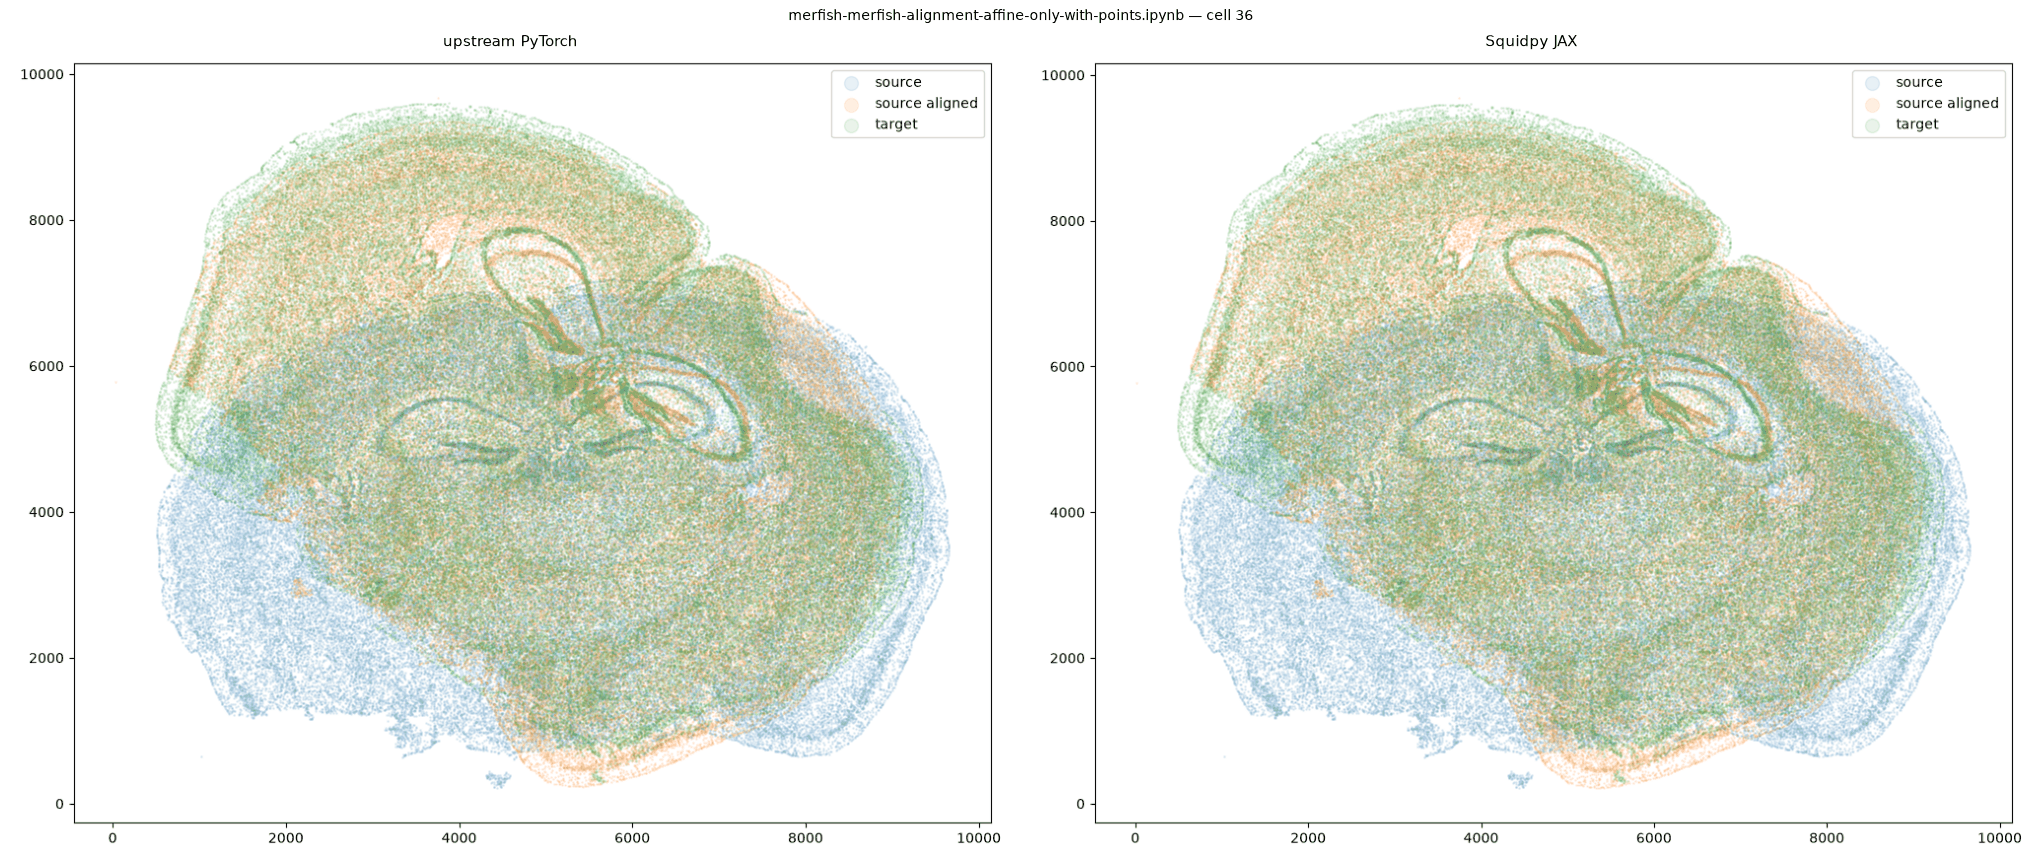

In [10]:
# plot results
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.1, label='source')
ax.scatter(xIaffine,yIaffine,s=1,alpha=0.1, label = 'source aligned')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label='target')
ax.legend(markerscale = 10)

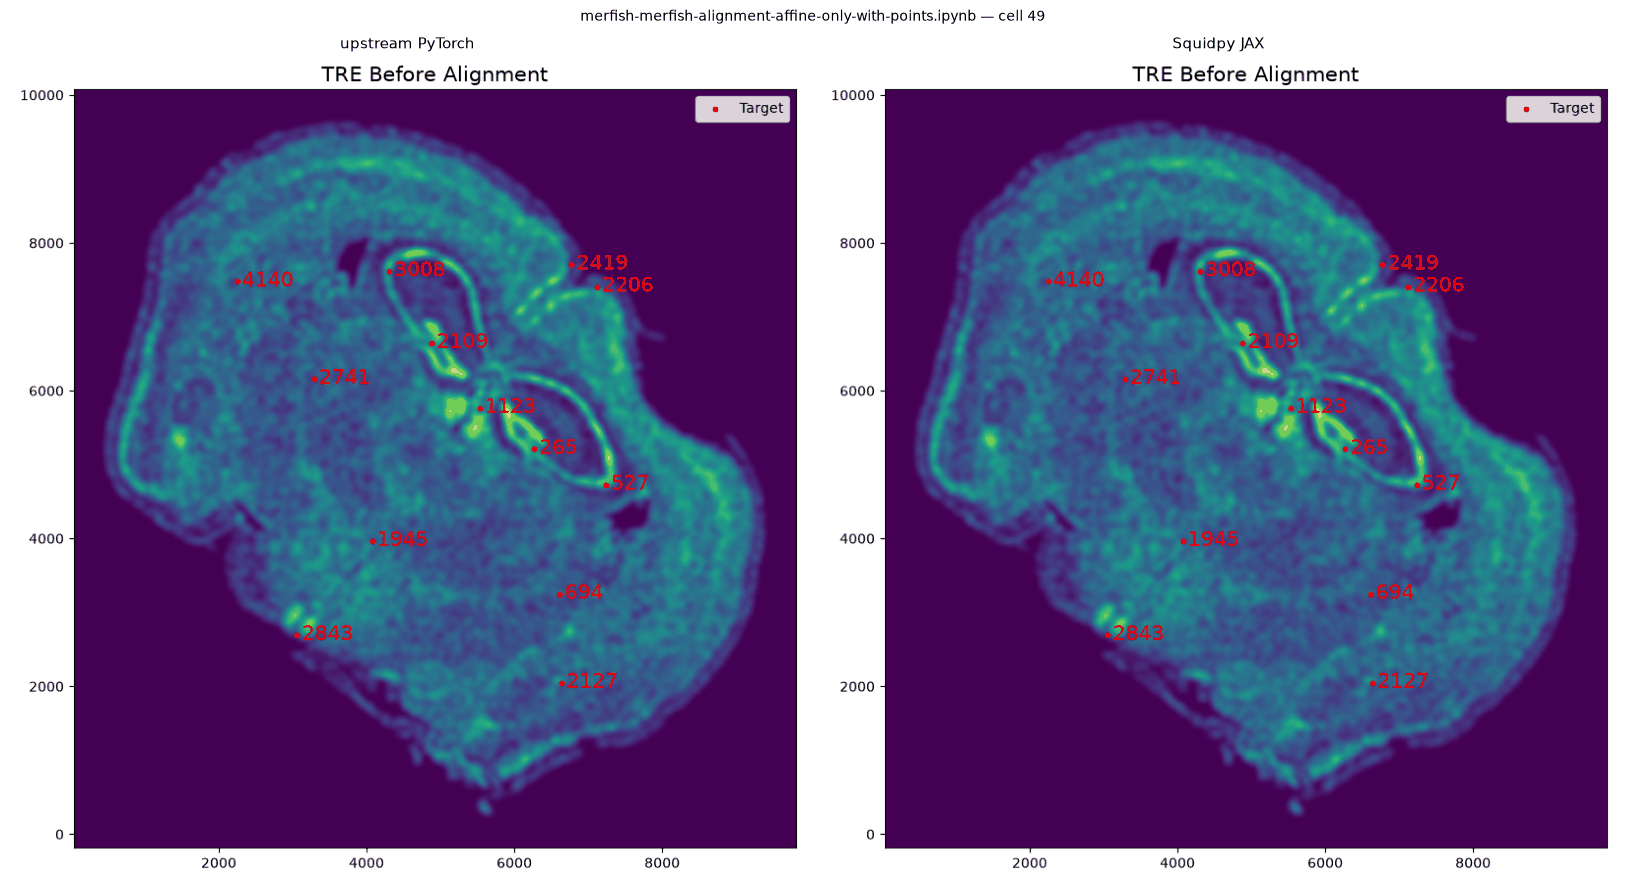

In [11]:
# plot

fig,ax = plt.subplots()
ax.imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) 

trans_offset_0 = mtransforms.offset_copy(ax.transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')

ax.scatter(pointsJ[:,1],pointsJ[:,0], c='red', s=10, label='Target')
#ax.scatter(pointsI[:,1],pointsI[:,0], c='orange', s=10, label='Source')

#k=0
#for i in pointsIlist.keys():
#    for j in range(len(pointsIlist[i])):
#        ax.text(pointsIlist[i][j][0], pointsIlist[i][j][1],f'{treBefore[k]:.0f}', c='red', transform=trans_offset_0, fontsize= 15)
#        k = k+1
        
for i in range(pointsJ.shape[0]):
    ax.text(pointsJ[i,1],pointsJ[i,0],f'{treBefore[i]:.0f}', c='red', transform=trans_offset_0, fontsize= 15)
        
ax.set_title('TRE Before Alignment', fontsize=15)

ax.legend(markerscale = 1)
# invert only rasterized images
ax.invert_yaxis()

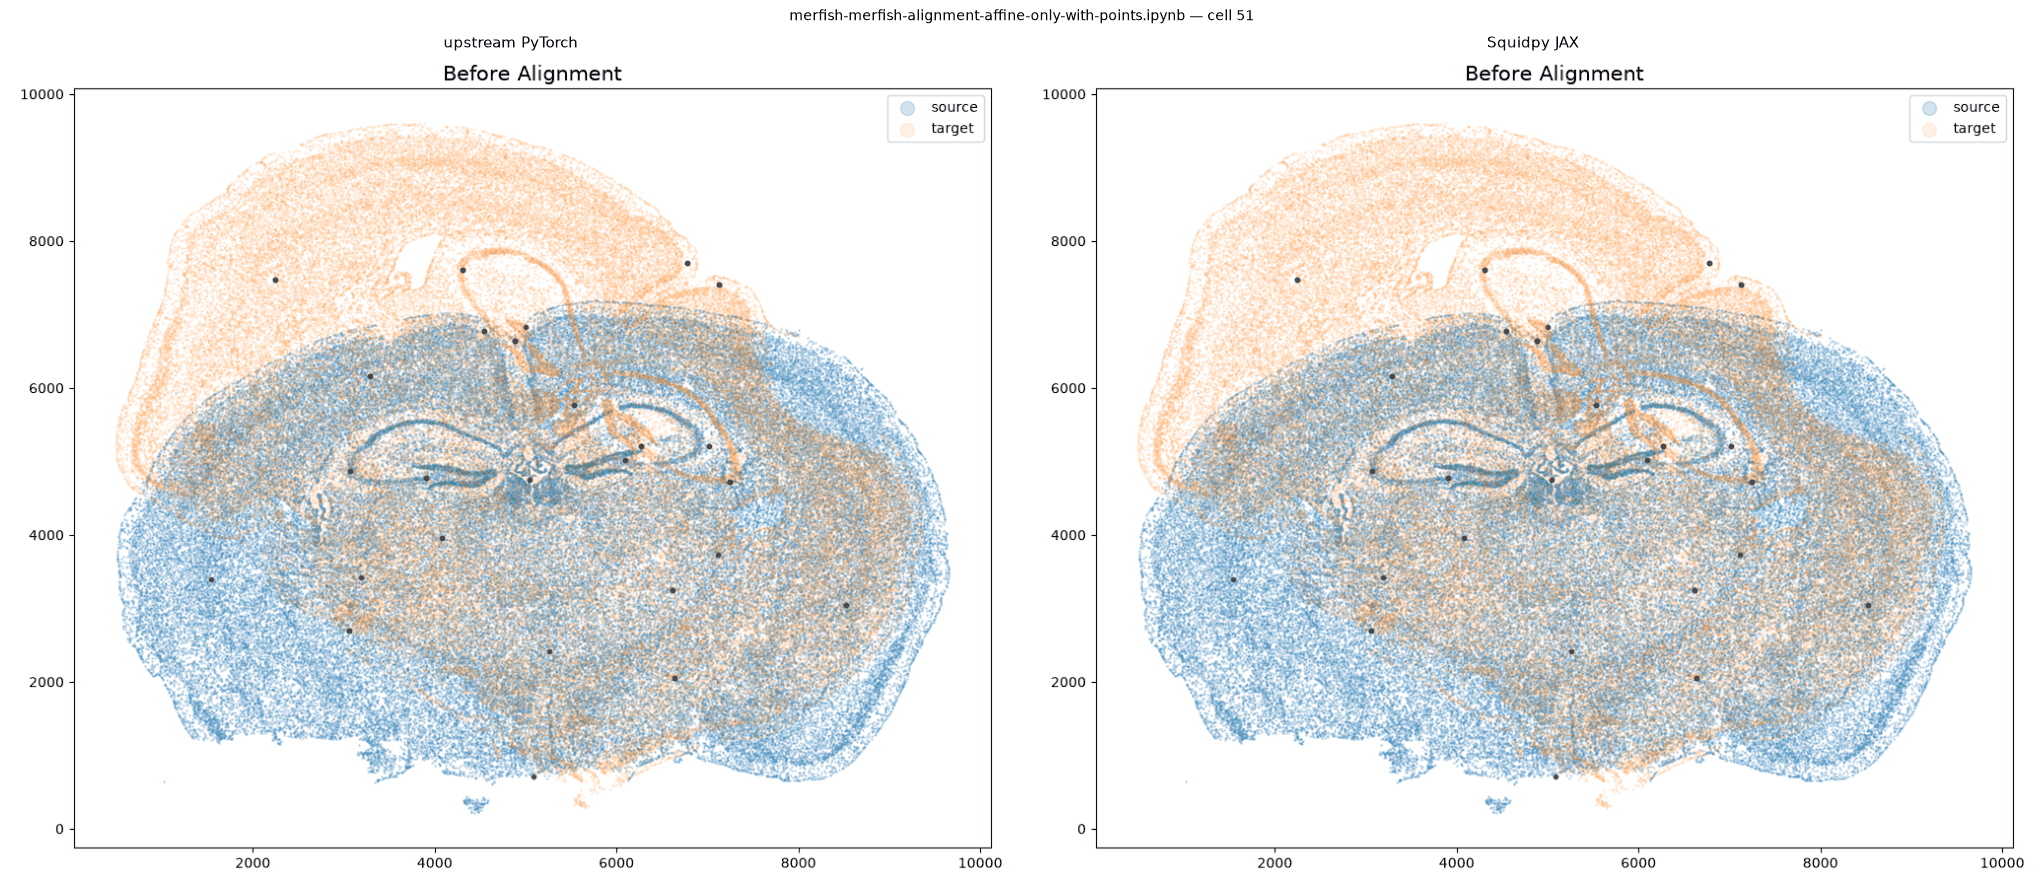

In [12]:
# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2, label='source')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label= 'target')
ax.legend(markerscale = 10)
ax.scatter(pointsI[:,1],pointsI[:,0], c='purple', s=10, label='Source')
ax.scatter(pointsJ[:,1],pointsJ[:,0], c='green', s=10, label='Target')
ax.set_title('Before Alignment', fontsize=15)

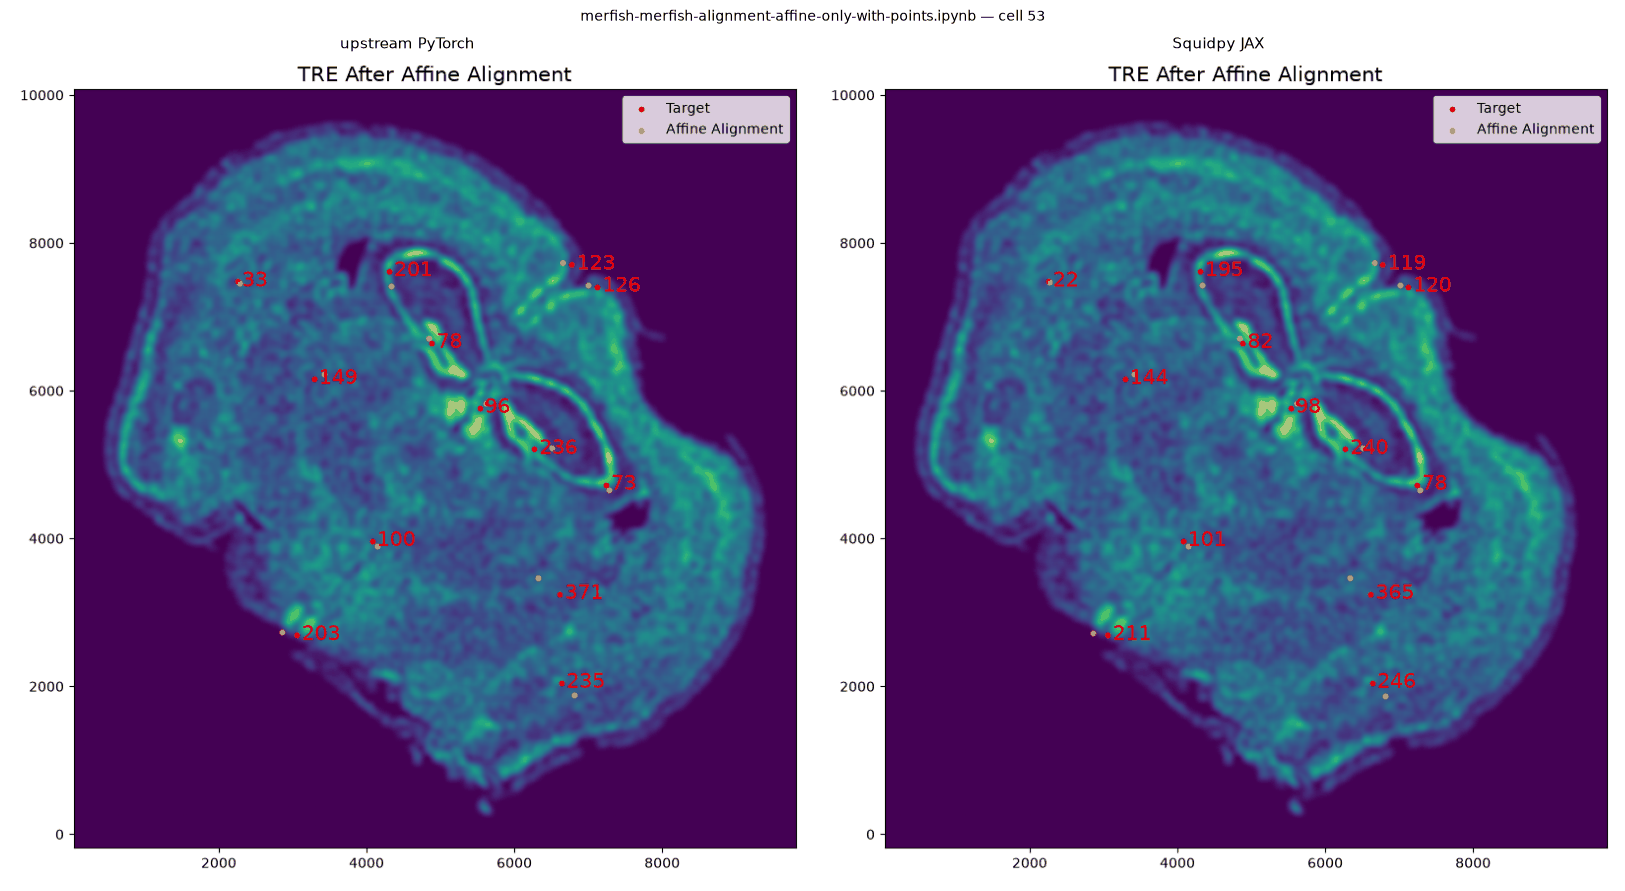

In [13]:
# plot

fig,ax = plt.subplots()
ax.imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) 

trans_offset_0 = mtransforms.offset_copy(ax.transData, fig=fig,
                                       x=0.05, y=-0.05, units='inches')

ax.scatter(pointsJ[:,1],pointsJ[:,0], c='red', s=10, label='Target')
ax.scatter(pointsIaffine[:,1],pointsIaffine[:,0], c='orange', s=10, label="Affine Alignment")

#k=0
#for i in pointsIlist.keys():
#    for j in range(len(pointsIlist[i])):
#        ax.text(pointsIlist[i][j][0], pointsIlist[i][j][1],f'{treAffine[k]:.0f}', c='red', transform=trans_offset_0, fontsize= 15)
#        k = k+1

for i in range(pointsJ.shape[0]):
    ax.text(pointsJ[i,1],pointsJ[i,0],f'{treAffine[i]:.0f}', c='red', transform=trans_offset_0, fontsize= 15)

ax.set_title('TRE After Affine Alignment', fontsize=15)

ax.legend(markerscale = 1)

# invert only rasterized images
ax.invert_yaxis()

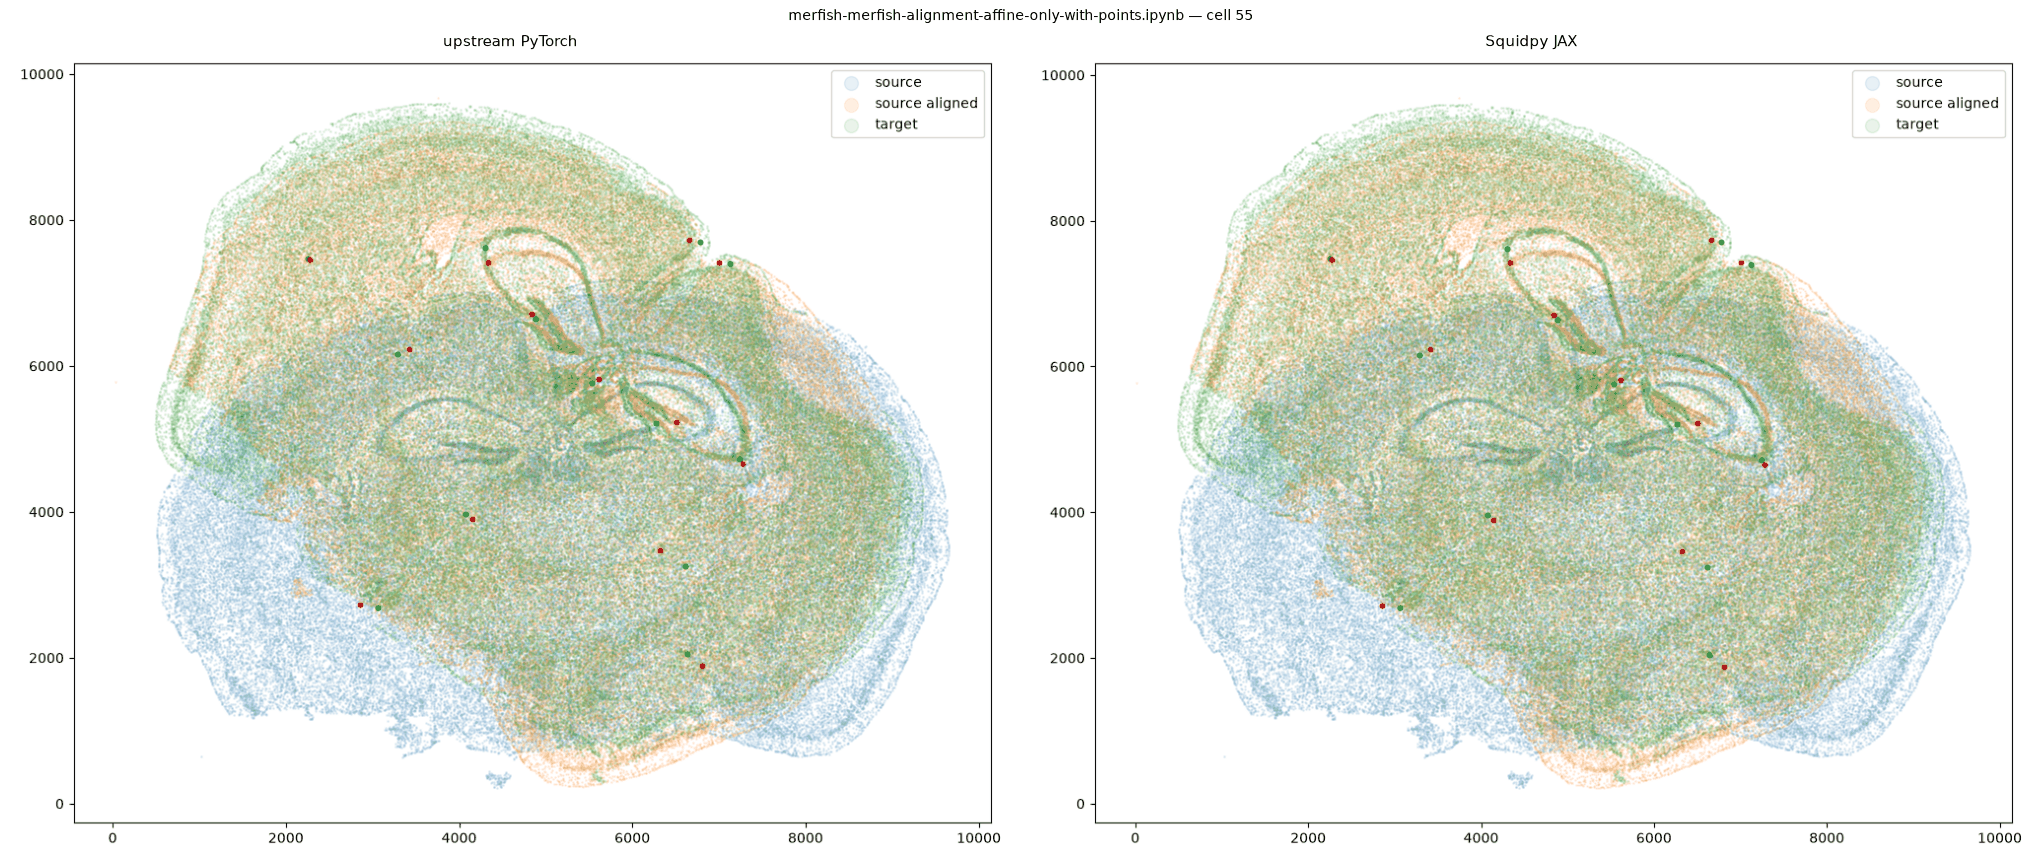

In [14]:
# plot results
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.1, label='source')
ax.scatter(xIaffine,yIaffine,s=1,alpha=0.1, label = 'source aligned')
ax.scatter(xJ,yJ,s=1,alpha=0.1, label='target')
ax.legend(markerscale = 10)
#ax.scatter(pointsI[:,1],pointsI[:,0], c='purple', s=10, label='Source')
ax.scatter(pointsJ[:,1],pointsJ[:,0], c='green', s=10, label='Target')
ax.scatter(pointsIaffine[:,1],pointsIaffine[:,0], c='red', s=10, label="Affine Alignment")

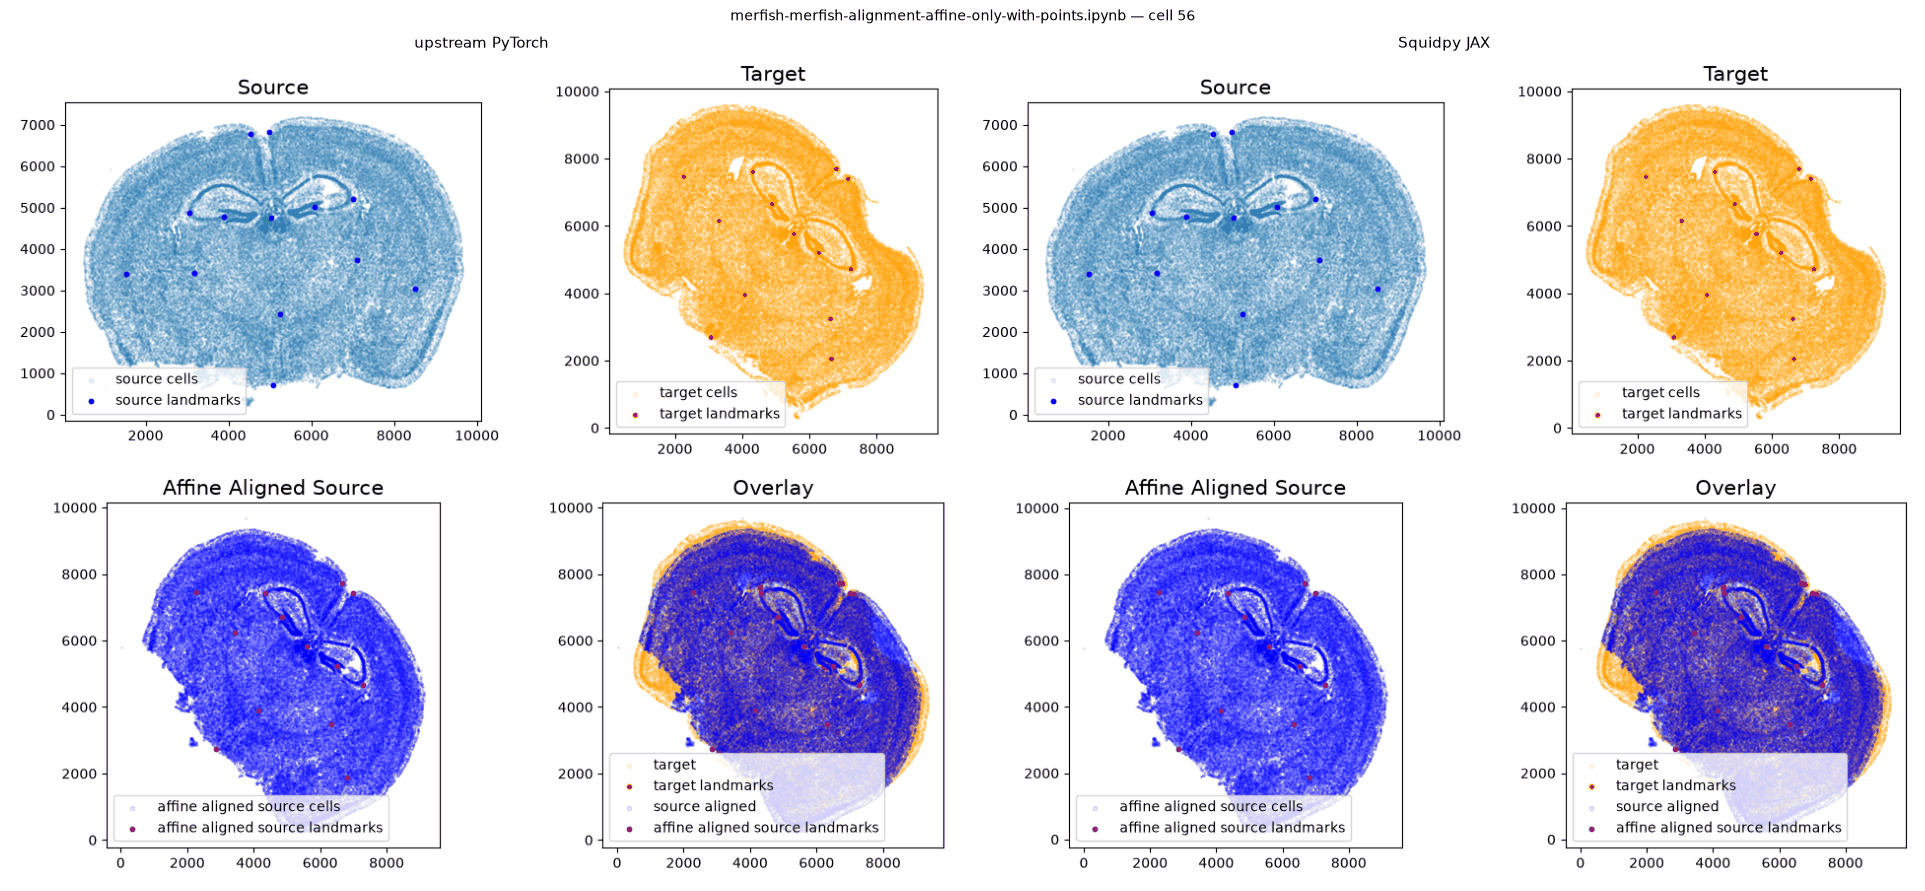

In [15]:
# plot results
fig,ax = plt.subplots(2,2)

#Source
ax[0][0].scatter(xI,yI,s=1,alpha=0.1, label='source cells')
ax[0][0].scatter(pointsI[:,1],pointsI[:,0], c='blue', s=10, label='source landmarks')
ax[0][0].set_title('Source', fontsize=15)
ax[0][0].set_aspect('equal')

lgnd = ax[0][0].legend(scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])

#Target
ax[0][1].scatter(xJ,yJ,s=1,alpha=0.1, label='target cells', c='orange')
ax[0][1].scatter(pointsJ[:,1],pointsJ[:,0], c='red', s=10, label='target landmarks')
ax[0][1].set_title('Target', fontsize=15)
ax[0][1].set_aspect('equal')

lgnd = ax[0][1].legend(scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])

#Affine Aligned Source
ax[1][0].scatter(xIaffine,yIaffine,s=1,alpha=0.1, label = 'affine aligned source cells', c='blue')
ax[1][0].scatter(pointsIaffine[:,1],pointsIaffine[:,0], c='purple', s=10, label="affine aligned source landmarks")
ax[1][0].set_title('Affine Aligned Source', fontsize=15)
ax[1][0].set_aspect('equal')

lgnd = ax[1][0].legend(scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])

#Overlay of Target and Affine Aligned Source
ax[1][1].scatter(xJ,yJ,s=1,alpha=0.1, label='target', c='orange')
ax[1][1].legend(markerscale = 10)
ax[1][1].scatter(pointsJ[:,1],pointsJ[:,0], c='red', s=10, label='target landmarks')

ax[1][1].scatter(xIaffine,yIaffine,s=1,alpha=0.1, label = 'source aligned', c='blue')
ax[1][1].scatter(pointsIaffine[:,1],pointsIaffine[:,0], c='purple', s=10, label="affine aligned source landmarks")
ax[1][1].set_title('Overlay', fontsize=15)
ax[1][1].set_aspect('equal')

lgnd = ax[1][1].legend(scatterpoints=1, fontsize=10)
for handle in lgnd.legend_handles:
    handle.set_sizes([10.0])